# Import Data

> download data to local device, and transform image to tensor datatype

In [ ]:
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.optim as optim

# Define transformation to convert images to tensors
transform = transforms.ToTensor()

# download training and test datasets
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

## Data Exploration

> Explore dataset

In [2]:
print(len(train_dataset))
print(len(test_dataset))

60000
10000


- There are 60,000 instances for training, and 10,000 instances for testing

In [3]:
image, label = train_dataset[0]
image.shape

torch.Size([1, 28, 28])

- Below is the way to display image from tensor type

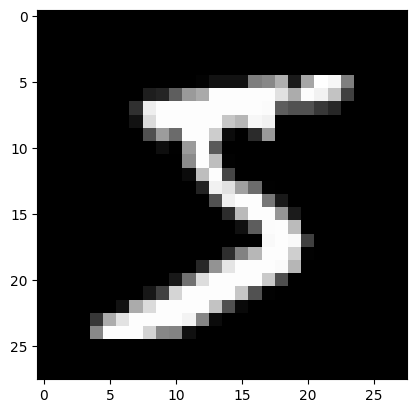

In [4]:
plt.imshow(image[0], cmap='gray')
plt.show()

- the original datatype for our trainjng and testing set, currently are tensor

In [5]:
train_dataset[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

- accesing tensor for our image

In [6]:
train_dataset[0][0]

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

- accessing label for our image

In [7]:
train_dataset[0][1]

5

- see how data is distributed across different label

In [8]:
train_labels = [label for _, label in train_dataset]

In [9]:
unique, counts = np.unique(train_labels, return_counts=True)

In [10]:
for digit, count in zip(unique, counts):
    print(f'{digit}: {count}')

0: 5923
1: 6742
2: 5958
3: 6131
4: 5842
5: 5421
6: 5918
7: 6265
8: 5851
9: 5949


- quiet balance, what about test?

In [11]:
test_labels = [label for _, label in test_dataset]
unique_test, counts_test = np.unique(test_labels, return_counts=True)
for digit, count in zip(unique_test, counts_test):
    print(f'{digit}: {count}')

0: 980
1: 1135
2: 1032
3: 1010
4: 982
5: 892
6: 958
7: 1028
8: 974
9: 1009


- height of image is 28, width is also 28 -> each image consists of 28*28 pixels -> we'll be using 28 * 28 nodes for input layer

# Training

## Create Data Loader

In [12]:
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Define NN Arch

- define NN architecture by subclassing nn.Module

In [13]:
class CNNDenseModel(nn.Module):
    def __init__(self):
        super(CNNDenseModel, self).__init__()
        self.network = nn.Sequential(
            #in_channel (for gray_scale: 1), out_channel (how many kernel or filter to use for sliding)
            #in [1, 28, 28]
            nn.Conv2d(1, 32, 3),
            #out [32, 26, 26] -> 26 come from 28 - 2 since the kernel sliding move 1 at a time with kernel size of 3
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            #out [32, 13, 13]

            nn.Conv2d(32, 64, 3),
            #out [32, 11, 11]
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            #out [64, 5, 5] - use floor division
 
            #Classification Head
            nn.Flatten(),

            nn.Linear(64 * 5  * 5, 128), # 128 is just approximate, any number would do
            nn.ReLU(),
            nn.Linear(128, 10)

        )
    
    def forward(self, x):
        return self.network(x)


In [14]:
model = CNNDenseModel()

model.train()  # Set to training mode 

CNNDenseModel(
  (network): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=1600, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [16]:
num_epochs = 5  

for epoch in range(num_epochs):  
    for images, labels in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
    
    correct = 0
    for images, labels in train_loader:
        pred = model(images).argmax(dim=1)
        correct += (pred == labels).sum().item()
    
    print(f'Epoch {epoch+1}: {100 * correct / len(train_dataset):.2f}%')

Epoch 1: 98.48%
Epoch 2: 98.91%
Epoch 3: 99.11%
Epoch 4: 99.44%
Epoch 5: 99.65%


# Testing

In [17]:
correct = 0
for images, labels in test_loader:
    pred = model(images).argmax(dim=1)
    correct += (pred == labels).sum().item()
    
print(f'Test Set Accuracy: {100 * correct / len(test_dataset):.2f}%')

Test Set Accuracy: 99.01%
